<a href="https://colab.research.google.com/github/hariniganesan31/Code-Alpha-Data-Science/blob/main/Sales_Prediction_using_Python_task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub pandas matplotlib seaborn scikit-learn

In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
path = kagglehub.dataset_download("bumba5341/advertisingcsv")

print("Dataset path:", path)
print("Files available:", os.listdir(path))

100%|██████████| 2.26k/2.26k [00:00<00:00, 1.81MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/bumba5341/advertisingcsv/versions/1
Files available: ['Advertising.csv']


In [4]:
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]

print("CSV files found:", csv_files)

file_path = os.path.join(path, csv_files[0])

data = pd.read_csv(file_path)

print(data.head())

CSV files found: ['Advertising.csv']
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [5]:
print("Column names:")
print(data.columns.tolist())

print("\nDataset shape:", data.shape)

print("\nMissing values:")
print(data.isnull().sum())

Column names:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Dataset shape: (200, 5)

Missing values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [6]:
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

data = data.loc[:, ~data.columns.str.contains("^unnamed")]

print(data.columns.tolist())
print(data.head())

['tv', 'radio', 'newspaper', 'sales']
      tv  radio  newspaper  sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


In [7]:
print(data.info())

print("\nBasic Statistics:")
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   tv         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Basic Statistics:
               tv       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


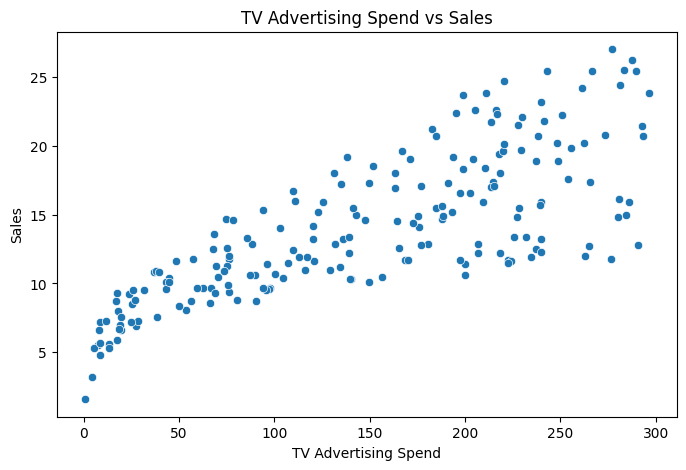

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=data, x="tv", y="sales")

plt.title("TV Advertising Spend vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.show()

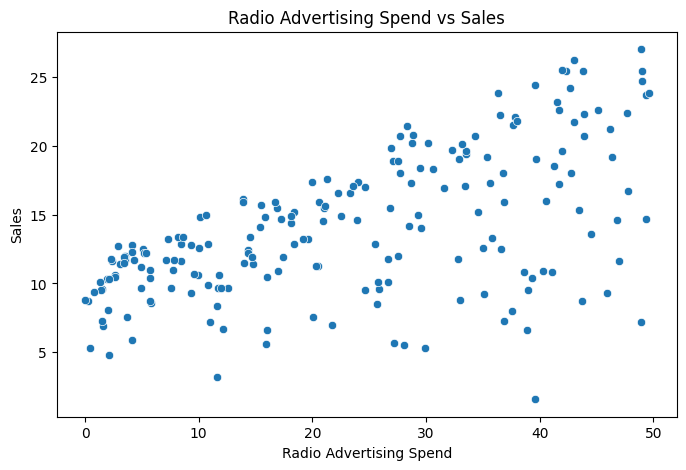

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=data, x="radio", y="sales")

plt.title("Radio Advertising Spend vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.show()

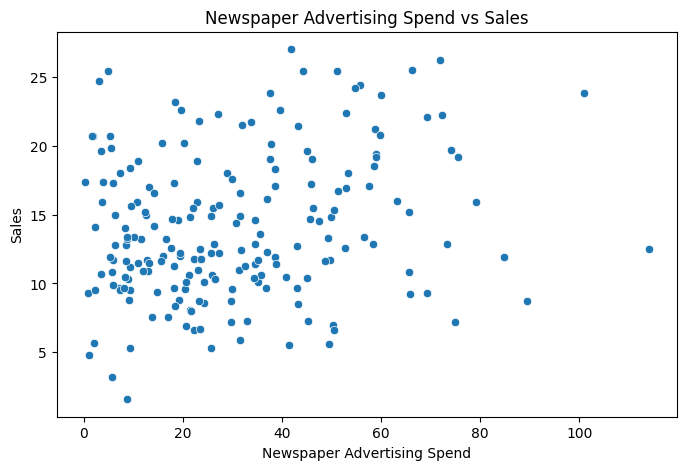

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=data, x="newspaper", y="sales")

plt.title("Newspaper Advertising Spend vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.show()

                 tv     radio  newspaper     sales
tv         1.000000  0.054809   0.056648  0.782224
radio      0.054809  1.000000   0.354104  0.576223
newspaper  0.056648  0.354104   1.000000  0.228299
sales      0.782224  0.576223   0.228299  1.000000


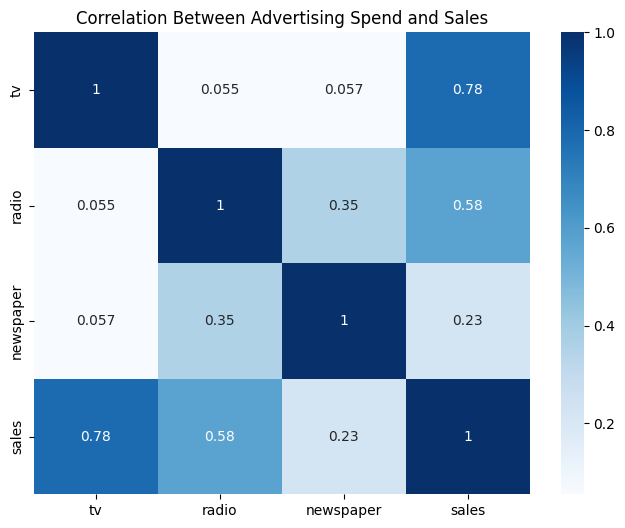

In [11]:
correlation = data.corr(numeric_only=True)

print(correlation)

plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap="Blues")

plt.title("Correlation Between Advertising Spend and Sales")
plt.show()

In [12]:
X = data[["tv", "radio", "newspaper"]]
y = data["sales"]

print("Input features:")
print(X.head())

print("\nOutput sales:")
print(y.head())

Input features:
      tv  radio  newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Output sales:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (160, 3)
Testing data shape: (40, 3)


In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [16]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print(results.head(10))

   Actual Sales  Predicted Sales
0          16.9        16.408024
1          22.4        20.889882
2          21.4        21.553843
3           7.3        10.608503
4          24.7        22.112373
5          12.6        13.105592
6          22.3        21.057192
7           8.4         7.461010
8          11.5        13.606346
9          14.9        15.155070


In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 2))

Model Evaluation Results
Mean Absolute Error (MAE): 1.46
Mean Squared Error (MSE): 3.17
Root Mean Squared Error (RMSE): 1.78
R² Score: 0.9


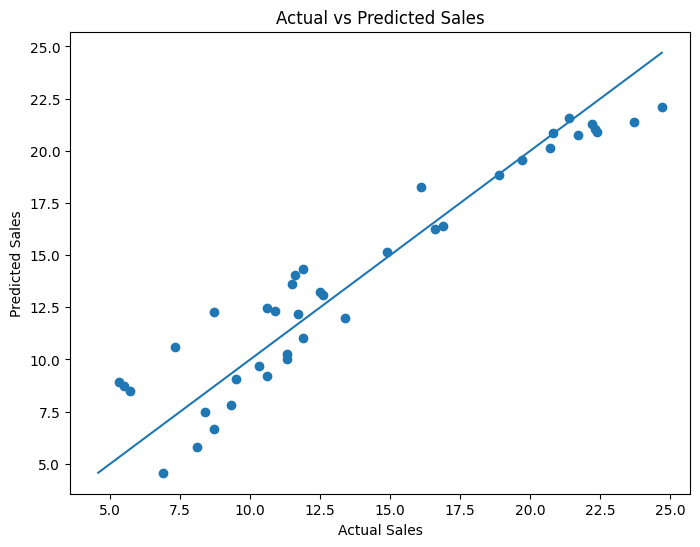

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum])

plt.show()

In [19]:
coefficients = pd.DataFrame({
    "Advertising Platform": X.columns,
    "Impact on Sales": model.coef_
})

coefficients = coefficients.sort_values(
    by="Impact on Sales",
    ascending=False
)

print(coefficients)

  Advertising Platform  Impact on Sales
1                radio         0.189195
0                   tv         0.044730
2            newspaper         0.002761


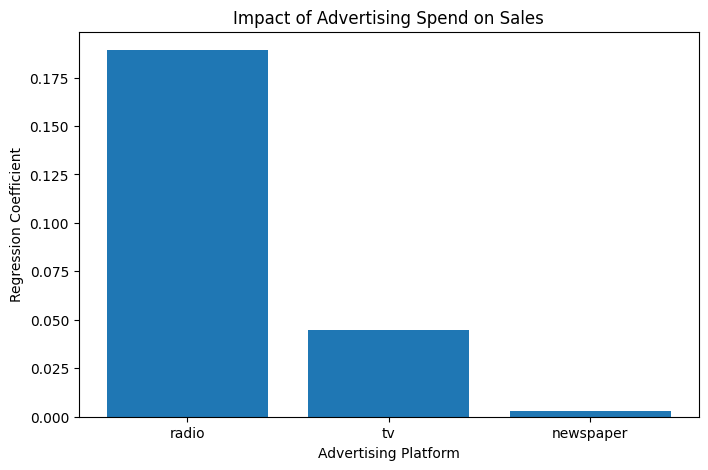

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(coefficients["Advertising Platform"], coefficients["Impact on Sales"])

plt.title("Impact of Advertising Spend on Sales")
plt.xlabel("Advertising Platform")
plt.ylabel("Regression Coefficient")

plt.show()

In [21]:
new_advertising_data = pd.DataFrame({
    "tv": [200],
    "radio": [40],
    "newspaper": [30]
})

predicted_sales = model.predict(new_advertising_data)

print("Predicted Sales:", round(predicted_sales[0], 2))

Predicted Sales: 19.58


In [22]:
print("FINAL INSIGHTS")
print("1. The model predicts sales using TV, radio, and newspaper advertising spend.")
print("2. The correlation matrix shows which advertising platforms have the strongest relationship with sales.")
print("3. Regression coefficients show how changes in advertising spending influence predicted sales.")
print("4. Businesses can prioritize the platforms with higher positive impact on sales.")
print("5. The model can help marketing teams estimate expected sales before deciding an advertising budget.")

FINAL INSIGHTS
1. The model predicts sales using TV, radio, and newspaper advertising spend.
2. The correlation matrix shows which advertising platforms have the strongest relationship with sales.
3. Regression coefficients show how changes in advertising spending influence predicted sales.
4. Businesses can prioritize the platforms with higher positive impact on sales.
5. The model can help marketing teams estimate expected sales before deciding an advertising budget.
